In [4]:
import pandas as pd
import matplotlib.pyplot as plt


# Load data from downloaded file 
data = pd.read_csv('NASA_data.csv', comment='#')

print(data.info())
print(data.columns)

#keep only default measurements for each planet since the nasa table contains each planet multiple times
data = data[data['default_flag'] == 1]

print(data.info())
# retrieve Radius, oribital period,equilibrium temperature, insolation flux, mass, orbit distance and 
# stellar properties (effective temp, metallicity, mass)
filtered_cols = ['pl_name', 'pl_radj', 'pl_orbper', 'pl_eqt', 'pl_insol', 'pl_massj', 'pl_orbsmax',
                 'st_teff', 'st_met', 'st_mass']
filtered_data = data[filtered_cols]
#print(filtered_data)

# filter for hot jupiters
# define a hot jupiter by 0,8 jupiter radius < radius < 2 jupiter radius, 
# oribal period < 10 and 0.34<mass < 11.8 jupiter mass
hot_jupiters = filtered_data[(filtered_data['pl_orbper'] < 10) & (filtered_data['pl_radj'] > 0.8)& 
                             (filtered_data['pl_radj'] < 2) &(filtered_data['pl_massj'] < 11.8) &
                             (filtered_data['pl_massj'] > 0.36) ]

#all planets with all columns that are hot jupiters

candidates = data[(filtered_data['pl_orbper'] < 10) & (filtered_data['pl_radj'] > 0.8) 
                  & (filtered_data['pl_radj'] < 2) &(filtered_data['pl_massj'] < 11.8) 
                  &(filtered_data['pl_massj'] > 0.36) ]
#handle NaNs 
# drop the whole line if radius or equilibrium temperature is missing
hot_jupiters = hot_jupiters.dropna(subset=['pl_radj', 'pl_eqt'])
print(hot_jupiters)



<class 'pandas.DataFrame'>
RangeIndex: 39476 entries, 0 to 39475
Columns: 108 entries, pl_name to releasedate
dtypes: float64(88), int64(4), str(16)
memory usage: 32.5 MB
None
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag',
       ...
       'sy_vmagerr2', 'sy_kmag', 'sy_kmagerr1', 'sy_kmagerr2', 'sy_gaiamag',
       'sy_gaiamagerr1', 'sy_gaiamagerr2', 'rowupdate', 'pl_pubdate',
       'releasedate'],
      dtype='str', length=108)
<class 'pandas.DataFrame'>
Index: 6138 entries, 0 to 39475
Columns: 108 entries, pl_name to releasedate
dtypes: float64(88), int64(4), str(16)
memory usage: 5.1 MB
None
               pl_name  pl_radj  pl_orbper  pl_eqt  pl_insol  pl_massj  \
278          CoRoT-1 b   1.4900   1.508956  1898.0       NaN     1.030   
294         CoRoT-11 b   1.4300   2.994330  1657.0       NaN     2.330   
297         CoRoT-12 b   1.4400   2.828042  1442.0       NaN

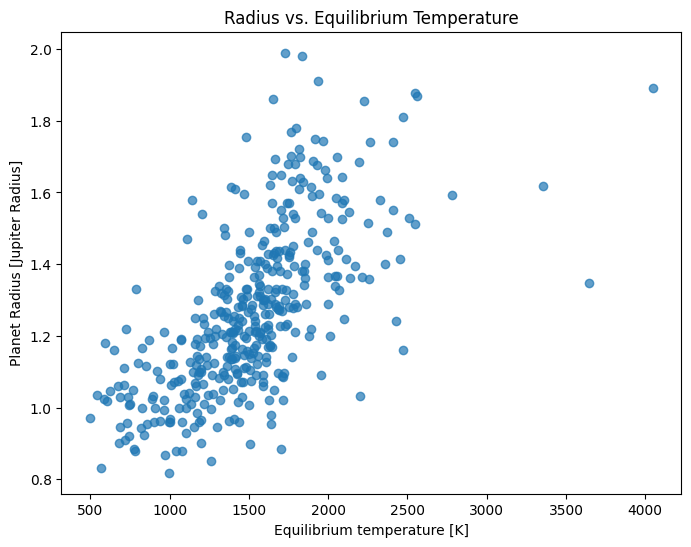

In [5]:
#create radius vs equilibrium temperature plot
#use plt.scatter instead of plt.plot 

plt.figure(figsize=(8,6))
plt.scatter(hot_jupiters['pl_eqt'],
            hot_jupiters['pl_radj'], alpha=0.7)
plt.xlabel("Equilibrium temperature [K]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.title("Radius vs. Equilibrium Temperature")
plt.show()

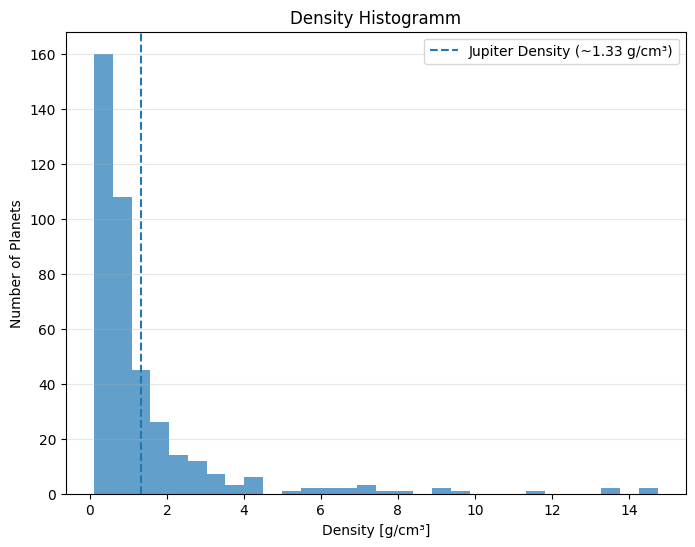

Mean Density: 1.37 g/cm³
Median Density: 0.75 g/cm³


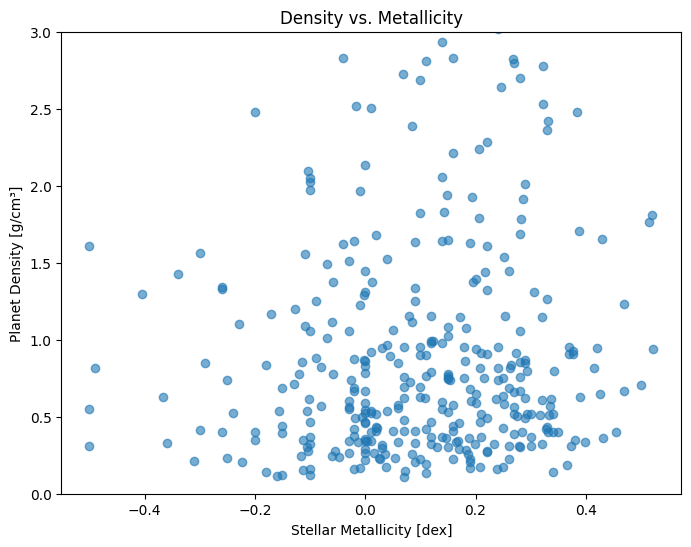

In [ ]:
# analyse density of hot jupiters
jupiter_mass_kg = 1.898e27
jupiter_radius_m = 6.991e7

# calculate Density in g/cm^3
volume_m3 = (4/3) * 3.14159 * (hot_jupiters['pl_radj']
                               * jupiter_radius_m)**3
mass_kg = hot_jupiters['pl_massj'] * jupiter_mass_kg
# Convert kg/m3 to g/cm3
hot_jupiters['density_gcm3'] = (mass_kg / volume_m3) / 1000 

# create a Histogram to see the general density distribution
plt.figure(figsize=(8, 6))
plt.hist(hot_jupiters['density_gcm3'], bins=30, alpha=0.7)

# add reference line for comparison
plt.axvline(1.33, linestyle='--', label=
            'Jupiter Density (~1.33 g/cm³)')

plt.xlabel('Density [g/cm³]')
plt.ylabel('Number of Planets')
plt.title('Density Histogramm')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# mean and median
print(f"Mean Density: {hot_jupiters['density_gcm3'].mean():.2f} g/cm³")
print(f"Median Density: {hot_jupiters['density_gcm3'].median():.2f} g/cm³")

# plot Density vs Metallicity
plt.figure(figsize=(8, 6))
scatter = plt.scatter(hot_jupiters['st_met'], 
                      hot_jupiters['density_gcm3'], alpha=0.7)
plt.xlabel('Stellar Metallicity [dex]')
plt.ylabel('Planet Density [g/cm³]')
plt.title('Density vs. Metallicity')

# limit y-axis to see the bulk of the data 
# and ignoring extreme outliers
plt.ylim(0, 3) 
plt.show()

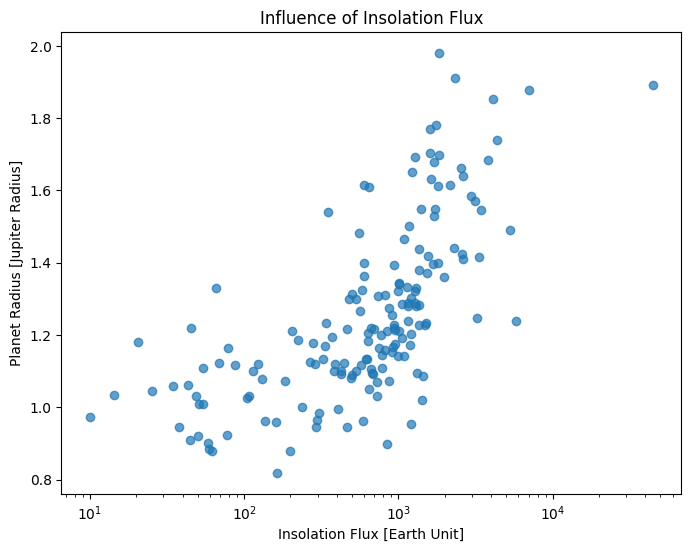

In [ ]:
#analyze influence of incident flux
#use pl_insol -> Insolation Flux (earth flux)
#print(data.columns)
plt.figure(figsize=(8,6))
plt.scatter(hot_jupiters['pl_insol'], 
            hot_jupiters['pl_radj'], alpha= 0.7)
plt.xlabel("Insolation Flux [Earth Unit]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.title("Influence of Insolation Flux")
plt.xscale('log')
plt.show()

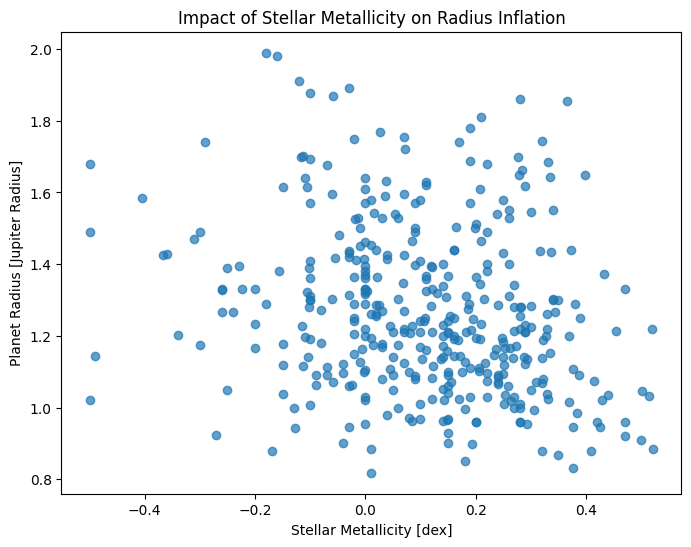

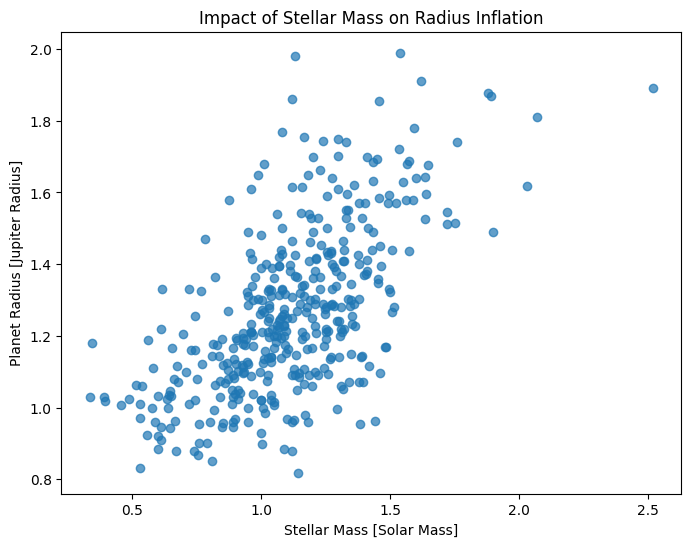

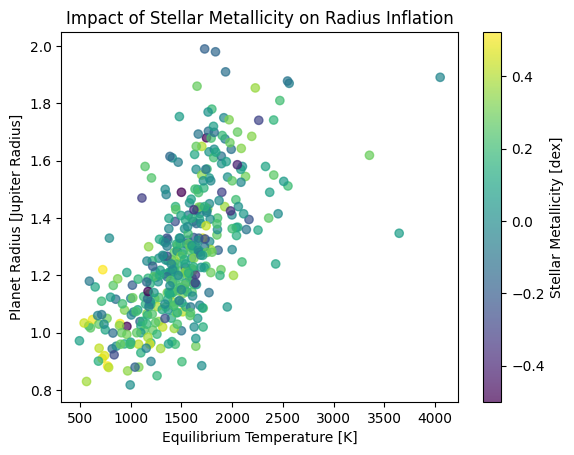

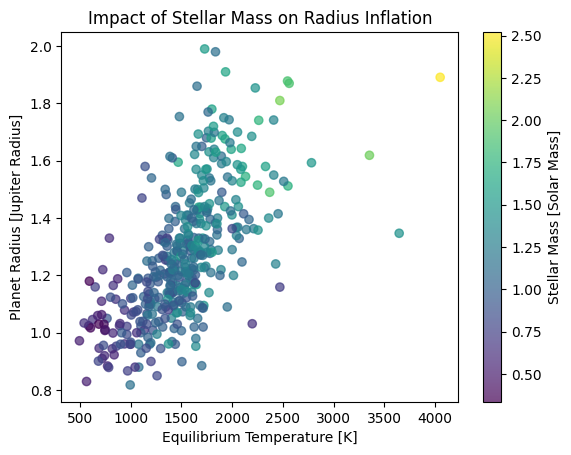

met_cat   pl_eqt           
Low Met   (491.445, 1206.0]    1.082280
          (1206.0, 1917.0]     1.359806
          (1917.0, 2628.0]     1.591467
          (3339.0, 4050.0]     1.891000
High Met  (491.445, 1206.0]    1.049606
          (1206.0, 1917.0]     1.257284
          (1917.0, 2628.0]     1.502909
          (3339.0, 4050.0]     1.483000
Name: pl_radj, dtype: float64


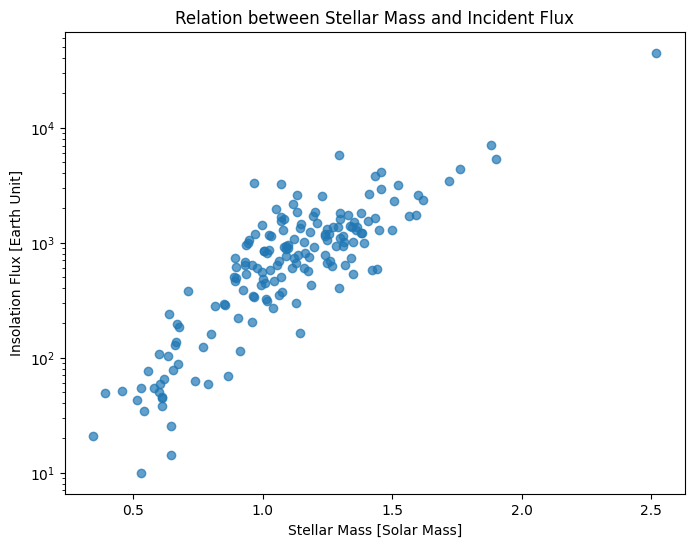

In [ ]:
#analyze the influence of stellar properties like mass or metallicity 

#plot radius vs metallicity
plt.figure(figsize=(8,6))
plt.scatter(hot_jupiters['st_met'], hot_jupiters['pl_radj'], alpha= 0.7)
plt.xlabel("Stellar Metallicity [dex]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.title("Impact of Stellar Metallicity on Radius Inflation")
plt.show()

#plot radius vs stellar mass
plt.figure(figsize=(8,6))
plt.scatter(hot_jupiters['st_mass'], hot_jupiters['pl_radj'], alpha= 0.7)
plt.xlabel("Stellar Mass [Solar Mass]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.title("Impact of Stellar Mass on Radius Inflation")
plt.show()

# plot to investigate the influence of metallicity using colourbars
scatter = plt.scatter(hot_jupiters['pl_eqt'], hot_jupiters['pl_radj'],
                      c=hot_jupiters['st_met'], alpha=0.7)
#Add colourbar to explain the colours
cbar = plt.colorbar(scatter)
cbar.set_label('Stellar Metallicity [dex]')
plt.xlabel("Equilibrium Temperature [K]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.title("Impact of Stellar Metallicity on Radius Inflation")
plt.show()

#plot to investigate the influence of 
# stellar mass using colourbars
scatter = plt.scatter(hot_jupiters['pl_eqt'], 
                      hot_jupiters['pl_radj'],
                      c=hot_jupiters['st_mass'], 
                      alpha=0.7)
# Add colourbar to explain colours
cbar = plt.colorbar(scatter)
cbar.set_label('Stellar Mass [Solar Mass]')
plt.xlabel("Equilibrium Temperature [K]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.title("Impact of Stellar Mass on Radius Inflation")
plt.show()

# Create a 'Metallicity Category'
hot_jupiters['met_cat'] = pd.cut(hot_jupiters['st_met'], 
                                 bins=[-1, 0, 1], 
                                 labels=['Low Met', 'High Met'])

# Group by temperature bins and metallicity category
analysis = hot_jupiters.groupby(['met_cat', pd.cut(hot_jupiters['pl_eqt'], bins=5)])['pl_radj'].mean()
print(analysis)

#plot stellar mass vs incident flux
plt.figure(figsize=(8,6))
plt.scatter(hot_jupiters['st_mass'], hot_jupiters['pl_insol'], alpha= 0.7)
plt.xlabel("Stellar Mass [Solar Mass]")
plt.ylabel("Insolation Flux [Earth Unit]")
plt.yscale('log')
plt.title("Relation between Stellar Mass and Incident Flux")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10876\2355801500.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


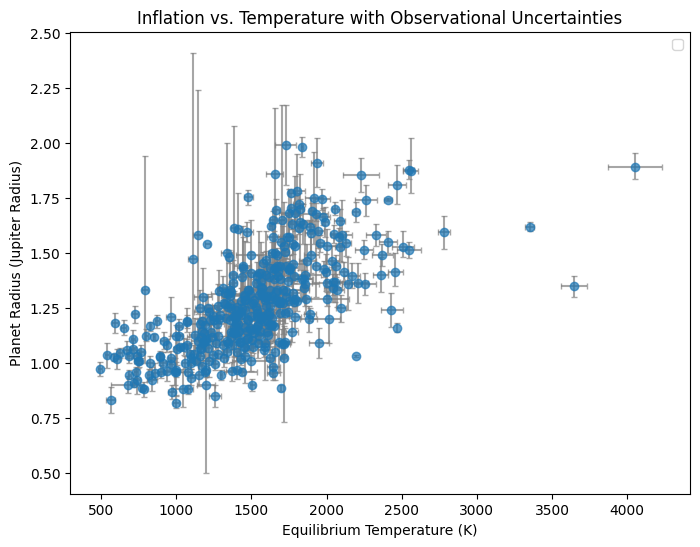

In [ ]:
#effect of observational uncertainties
#print(data.columns)
 
plt.figure(figsize=(8, 6))

# need to handle the case where error values might be NaN
# use abs because pl_radjerr2 is usually negative in the data
y_err = [abs(candidates['pl_radjerr2']), candidates['pl_radjerr1']]
x_err = [abs(candidates['pl_eqterr2']), candidates['pl_eqterr1']]

plt.errorbar(candidates['pl_eqt'], candidates['pl_radj'], 
             yerr=y_err, xerr=x_err,
             fmt='o', ecolor='gray', alpha=0.7, capsize=2)

plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Radius (Jupiter Radius)")
plt.title
("Inflation vs. Temperature with Observational Uncertainties")
plt.legend()
plt.show()

#print(data.columns)
#filtered_columns= data[['pl_radjerr1', 'pl_radjerr2', 'pl_radj']]
#print(filtered_columns.info)